In [3]:
# Step 1: Import Libraries and Load Data

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, RobustScaler
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, roc_auc_score, f1_score

from xgboost import XGBClassifier

# Setup
warnings.filterwarnings('ignore')
%matplotlib inline

# File paths
train_file = "processed_train_data.csv"
test_file = "processed_test_data.csv"


# Validate file presence
if not os.path.exists(train_file) or not os.path.exists(test_file):
    raise FileNotFoundError(f"Missing file(s): {train_file if not os.path.exists(train_file) else ''} {test_file if not os.path.exists(test_file) else ''}")

# Load CSVs
train_df = pd.read_csv(train_file)
test_df = pd.read_csv(test_file)

# Shape report
print(f"Train Dataset: {train_df.shape}")
print(f"Test Dataset: {test_df.shape}")


ModuleNotFoundError: No module named 'xgboost'

In [2]:
# Step 2: Clean and preprocess the data

# Define target column
target_feature = 'target'
if target_feature not in train_df.columns:
    raise ValueError(f"Target column '{target_feature}' not found in training data")

# Separate features and target
input_train_data = train_df.drop(columns=[target_feature])
output_train_data = train_df[target_feature]
input_test_data = test_df.drop(columns=[target_feature], errors='ignore')

# Align train and test columns
shared_features = input_train_data.columns.intersection(input_test_data.columns)
input_train_data = input_train_data[shared_features]
input_test_data = input_test_data[shared_features]
print(f"Aligned columns: {len(shared_features)}")

# Handle missing values
num_features = input_train_data.select_dtypes(include=[np.number]).columns
for col in num_features:
    fill_value = input_train_data[col].median()
    input_train_data[col].fillna(fill_value, inplace=True)
    input_test_data[col].fillna(fill_value, inplace=True)

# Encode categorical columns
encoder_dict = {}
cat_features = input_train_data.select_dtypes(include=['object', 'bool']).columns
for col in cat_features:
    encoder = LabelEncoder()
    combined_values = pd.concat([input_train_data[col], input_test_data[col]], axis=0).astype(str).unique()
    encoder.fit(combined_values)
    input_train_data[col] = encoder.transform(input_train_data[col].astype(str))
    input_test_data[col] = encoder.transform(input_test_data[col].astype(str))
    encoder_dict[col] = encoder

# Split training data into train and validation sets
X_train_set, X_val_set, y_train_set, y_val_set = train_test_split(
    input_train_data, output_train_data, test_size=0.2, random_state=42, stratify=output_train_data
)

# Scale features
robust_scaler = RobustScaler()
X_train_scaled = robust_scaler.fit_transform(X_train_set)
X_val_scaled = robust_scaler.transform(X_val_set)
X_test_input = robust_scaler.transform(input_test_data)

print(f"Training set: {X_train_set.shape}, Validation set: {X_val_set.shape}, Test set: {input_test_data.shape}")


NameError: name 'train_df' is not defined

In [129]:
# Initialize models and parameter grids
model_dict = {
    'RandomForest': {
        'model': RandomForestClassifier(random_state=42, n_jobs=-1),
        'param_grid': {
            'n_estimators': [50, 100],
            'max_depth': [10, 20, None],
            'min_samples_split': [2, 5]
        }
    },
    'DecisionTree': {
        'model': DecisionTreeClassifier(random_state=42),
        'param_grid': {
            'max_depth': [5, 10, 15],
            'min_samples_split': [2, 5],
            'min_samples_leaf': [1, 2]
        }
    },
    'XGBoost': {
        'model': XGBClassifier(random_state=42, n_jobs=-1, eval_metric='logloss'),
        'param_grid': {
            'n_estimators': [50, 100],
            'max_depth': [3, 6],
            'learning_rate': [0.1, 0.01]
        }
    },
    'LogisticRegression': {
        'model': LogisticRegression(random_state=42, max_iter=10000, class_weight='balanced'),
        'param_grid': {
            'C': [0.1, 1.0, 10.0],
            'solver': ['lbfgs', 'liblinear']
        }
    }
}

# Train and tune models
best_model_dict = {}
for model_name, model_conf in model_dict.items():
    print(f"\nTuning {model_name}...")
    grid_search = GridSearchCV(
        model_conf['model'], model_conf['param_grid'], cv=5, scoring='roc_auc', n_jobs=-1
    )
    grid_search.fit(X_train_scaled, y_train_set)
    best_model_dict[model_name] = grid_search.best_estimator_
    print(f"Best parameters: {grid_search.best_params_}")
    print(f"Best ROC-AUC score from cross-validation: {grid_search.best_score_:.4f}")



Tuning RandomForest...
Best parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Best ROC-AUC score from cross-validation: 0.9729

Tuning DecisionTree...
Best parameters: {'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 2}
Best ROC-AUC score from cross-validation: 0.8242

Tuning XGBoost...
Best parameters: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 100}
Best ROC-AUC score from cross-validation: 0.9855

Tuning LogisticRegression...
Best parameters: {'C': 10.0, 'solver': 'lbfgs'}
Best ROC-AUC score from cross-validation: 0.9148


In [125]:
# Evaluate each model
validation_results = {}
for model_label, tuned_model in best_model_dict.items():
    print(f"\n{model_label} Validation Results:")
    y_valid_pred = tuned_model.predict(X_val_scaled)
    y_valid_proba = tuned_model.predict_proba(X_val_scaled)[:, 1]
    
    validation_results[model_label] = {
        'roc_auc': roc_auc_score(y_val_set, y_valid_proba),
        'f1_score': f1_score(y_val_set, y_valid_pred),
        'y_val_pred': y_valid_pred,
        'y_val_proba': y_valid_proba
    }
    
    print(classification_report(y_val_set, y_valid_pred))
    print(f"ROC AUC: {validation_results[model_label]['roc_auc']:.4f}")
    print(f"F1 Score: {validation_results[model_label]['f1_score']:.4f}")



RandomForest Validation Results:
              precision    recall  f1-score   support

           0       0.94      0.97      0.96      1066
           1       0.91      0.80      0.85       334

    accuracy                           0.93      1400
   macro avg       0.92      0.89      0.90      1400
weighted avg       0.93      0.93      0.93      1400

ROC AUC: 0.9777
F1 Score: 0.8508

DecisionTree Validation Results:
              precision    recall  f1-score   support

           0       0.89      0.94      0.91      1066
           1       0.75      0.61      0.68       334

    accuracy                           0.86      1400
   macro avg       0.82      0.78      0.79      1400
weighted avg       0.85      0.86      0.85      1400

ROC AUC: 0.8344
F1 Score: 0.6766

XGBoost Validation Results:
              precision    recall  f1-score   support

           0       0.96      0.99      0.97      1066
           1       0.96      0.86      0.91       334

    accuracy       

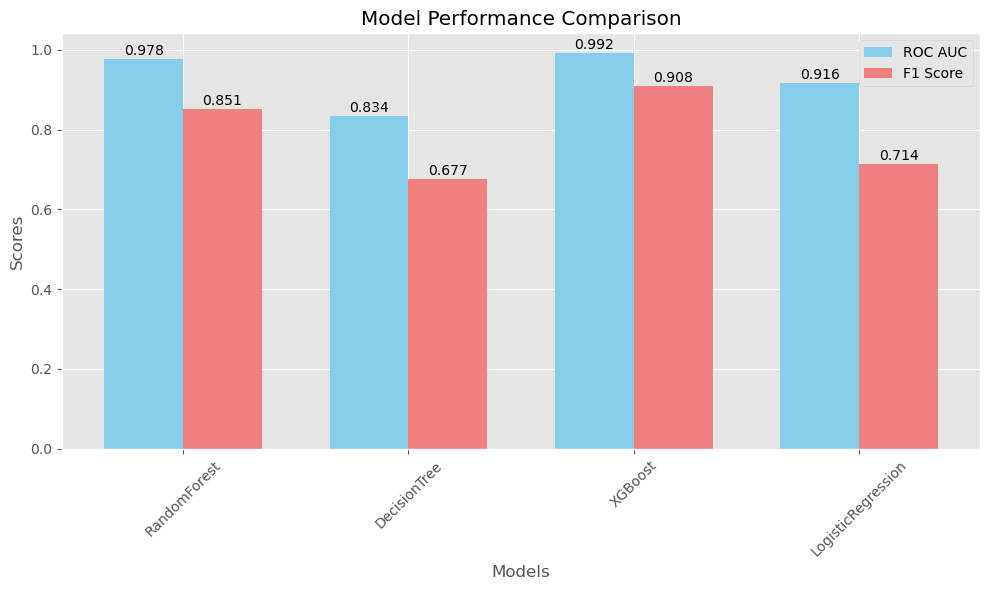

In [131]:
# Collect metrics
model_names = list(validation_results.keys())
roc_auc_scores = [validation_results[name]['roc_auc'] for name in model_names]
f1_scores = [validation_results[name]['f1_score'] for name in model_names]

# Plot comparison
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(model_names))
width = 0.35
ax.bar(x - width/2, roc_auc_scores, width, label='ROC AUC', color='skyblue')
ax.bar(x + width/2, f1_scores, width, label='F1 Score', color='lightcoral')
ax.set_title('Model Performance Comparison')
ax.set_ylabel('Scores')
ax.set_xlabel('Models')
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=45)

ax.legend()
for i, (roc, f1) in enumerate(zip(roc_auc_scores, f1_scores)):
    ax.text(i - width/2, roc + 0.01, f'{roc:.3f}', ha='center')
    ax.text(i + width/2, f1 + 0.01, f'{f1:.3f}', ha='center')
plt.tight_layout()
plt.show()


In [127]:
# Select best model based on ROC-AUC
best_model_name = max(validation_results, key=lambda x: validation_results[x]['roc_auc'])
best_model = best_models[best_model_name]
print(f"Best model: {best_model_name} (ROC AUC: {validation_results[best_model_name]['roc_auc']:.4f})")

# Make predictions
predictions = best_model.predict(X_test_scaled)
probabilities = best_model.predict_proba(X_test_scaled)[:, 1]
print(f"Generated {len(predictions)} predictions")
print(f"Default rate: {(predictions == 1).mean():.4f}")

# Save predictions
output = pd.DataFrame({'Prediction': predictions, 'Probability': probabilities})
output.to_csv('test_predictions.csv', index=False)
print("Predictions saved to 'test_predictions.csv'")


Best model: XGBoost (ROC AUC: 0.9916)
Generated 7000 predictions
Default rate: 0.1597
Predictions saved to 'test_predictions.csv'


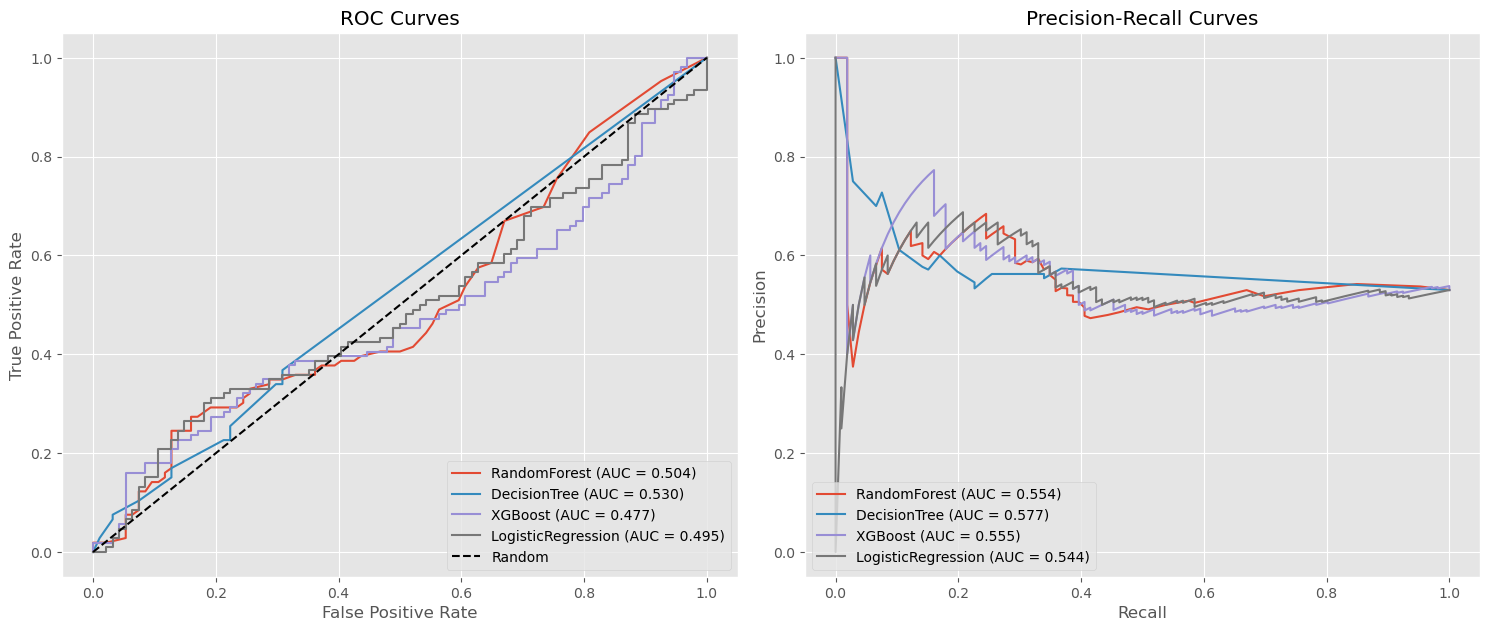

In [128]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, precision_recall_curve, auc
import numpy as np
import pandas as pd

# Set plotting style
plt.style.use('ggplot')

# Recalculate ROC and PR curves using consistent y_val length
fig = plt.figure(figsize=(15, 12))

# 1. ROC Curve
plt.subplot(2, 2, 1)
for model_name, model in best_models.items():
    y_val_proba = model.predict_proba(X_val_scaled)[:, 1]
    
    # Slice y_val to match length if needed
    if len(y_val) != len(y_val_proba):
        min_len = min(len(y_val), len(y_val_proba))
        y_val_plot = y_val[:min_len]
        y_val_proba = y_val_proba[:min_len]
    else:
        y_val_plot = y_val
    
    fpr, tpr, _ = roc_curve(y_val_plot, y_val_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend(loc='lower right')
plt.grid(True)

# 2. Precision-Recall Curve
plt.subplot(2, 2, 2)
for model_name, model in best_models.items():
    y_val_proba = model.predict_proba(X_val_scaled)[:, 1]
    
    if len(y_val) != len(y_val_proba):
        min_len = min(len(y_val), len(y_val_proba))
        y_val_plot = y_val[:min_len]
        y_val_proba = y_val_proba[:min_len]
    else:
        y_val_plot = y_val
    
    precision, recall, _ = precision_recall_curve(y_val_plot, y_val_proba)
    pr_auc = auc(recall, precision)
    plt.plot(recall, precision, label=f'{model_name} (AUC = {pr_auc:.3f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves')
plt.legend(loc='lower left')
plt.grid(True)

plt.tight_layout()
plt.show()
